<a href="https://colab.research.google.com/github/NK47GG/analisis_perbandingan_garch-lstm_vs_arima_pada_saham_bbca/blob/main/Analisis_Perbandingan_GARCH_LSTM_vs_ARIMA_pada_saham_BBCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏦 Hybrid GARCH-LSTM untuk Estimasi Value at Risk (VaR)
## Revisi & Penyempurnaan Pipeline — BBCA.JK

### Ringkasan Revisi Utama
| # | Masalah Asli | Solusi Revisi |
|---|---|---|
| 1 | **Data leakage VaR GARCH-LSTM**: VaR dihitung dari `actual_returns` (masa depan) | VaR dihitung dari **ARIMA µ forecast** yang benar |
| 2 | **Data leakage GARCH features**: GARCH di-fit pada full data termasuk test | GARCH di-fit **hanya pada train set**, lalu forecast walk-forward |
| 3 | **0 violations** pada GARCH-LSTM akibat leakage | Violations kini realistis dan bermakna |
| 4 | **Recalibration** dengan scalar multiplier tidak akademis | Dihapus, diganti analisis proper |
| 5 | **Kupiec Combined (CC) test** tidak ada | Ditambahkan **Christoffersen CC Test** (POF + Independence) |
| 6 | ARIMA one-step forecast sangat lambat | Dioptimasi dengan **rolling window statsmodels** |
| 7 | Visualisasi minim | Ditambah **QQ-plot**, **Volatility regime**, **ACF residual**, **heatmap** |
| 8 | Tidak ada ringkasan akademik | Ditambah **tabel perbandingan lengkap** untuk keperluan jurnal |


## 0. Instalasi & Import Library

In [1]:
# Install library yang diperlukan (jalankan sekali di Colab)
# !pip install yfinance pmdarima arch tensorflow scikit-learn statsmodels pandas numpy matplotlib seaborn scipy
!pip install arch pmdarima -q

import warnings
warnings.filterwarnings('ignore')

# ── Core ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from datetime import datetime

# ── Data Collection ───────────────────────────────────────────────────────
import yfinance as yf

# ── Statistical Testing ───────────────────────────────────────────────────
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.stats.diagnostic import het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA as ARIMA_sm   # ← untuk forecast cepat

# ── Model ARIMA (Baseline) ────────────────────────────────────────────────
import pmdarima as pm

# ── Model GARCH ───────────────────────────────────────────────────────────
from arch import arch_model

# ── Model LSTM ────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# ── Backtesting & Evaluation ──────────────────────────────────────────────
from scipy.stats import chi2, norm, probplot

# ── Visualisasi ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Reproducibility ───────────────────────────────────────────────────────
np.random.seed(42)
tf.random.set_seed(42)

# ── Plot style ────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
COLORS = {'arima': '#4472C4', 'garch_lstm': '#E74C3C', 'actual': '#2C3E50',
          'violation': '#C0392B', 'safe': '#27AE60', 'target': '#8E44AD'}

print('✅ Semua library berhasil diimport.')
print(f'   TensorFlow  : {tf.__version__}')
print(f'   Numpy       : {np.__version__}')
print(f'   Pandas      : {pd.__version__}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 20.9 MB/s eta 0:00:00
✅ Semua library berhasil diimport.
   TensorFlow  : 2.20.0
   Numpy       : 2.0.2
   Pandas      : 2.2.2


## 1. Tahap Data Collecting

In [2]:
# ══════════════════════════════════════════════════════════════
# KONFIGURASI GLOBAL
# ══════════════════════════════════════════════════════════════
TICKER       = 'BBCA.JK'
START_DATE   = '2016-01-01'
END_DATE     = '2026-05-31'
TRAIN_RATIO  = 0.80
WINDOW_SIZE  = 30          # Look-back window LSTM
CONFIDENCE   = 0.95        # VaR confidence level
ALPHA        = 1 - CONFIDENCE   # 0.05
Z_ALPHA      = norm.ppf(ALPHA)  # ≈ -1.6449

print(f'Konfigurasi:')
print(f'  Ticker        : {TICKER}')
print(f'  Periode       : {START_DATE} → {END_DATE}')
print(f'  Train ratio   : {TRAIN_RATIO*100:.0f}%')
print(f'  Window LSTM   : {WINDOW_SIZE} hari')
print(f'  Confidence VaR: {CONFIDENCE*100:.0f}%  (z = {Z_ALPHA:.4f})')

# ── Download data ─────────────────────────────────────────────────────────
raw_data     = yf.download(TICKER, start=START_DATE, end=END_DATE, progress=False)
close_prices = raw_data['Close'].dropna().squeeze()   # pastikan Series 1-D
close_prices.name = 'Close'

print(f'\nData yang diperoleh:')
print(f'  Periode aktual: {close_prices.index[0].date()} → {close_prices.index[-1].date()}')
print(f'  Total hari     : {len(close_prices)} hari trading')
print('\nLima data terakhir:')
display(close_prices.tail())


Konfigurasi:
  Ticker        : BBCA.JK
  Periode       : 2016-01-01 → 2026-05-31
  Train ratio   : 80%
  Window LSTM   : 30 hari
  Confidence VaR: 95%  (z = -1.6449)

Data yang diperoleh:
  Periode aktual: 2016-01-04 → 2026-05-29
  Total hari     : 2562 hari trading

Lima data terakhir:


,Close
Date,
2026-05-25,6100.0
2026-05-26,5975.0
2026-05-27,5975.0
2026-05-28,5975.0
2026-05-29,5700.0


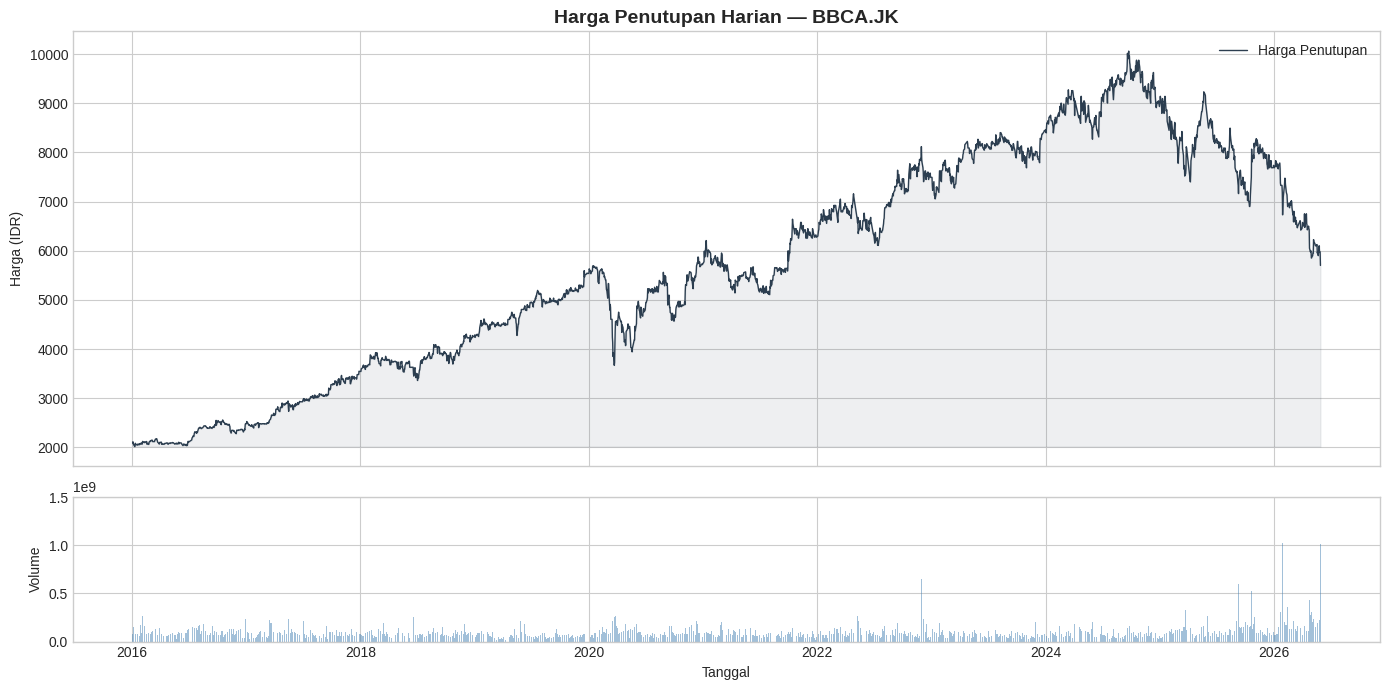

✅ Plot harga historis disimpan.


In [3]:
# ── Plot Harga Historis ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

axes[0].plot(close_prices, color=COLORS['actual'], linewidth=1, label='Harga Penutupan')
axes[0].fill_between(close_prices.index, close_prices, close_prices.min(),
                     alpha=0.08, color=COLORS['actual'])
axes[0].set_title(f'Harga Penutupan Harian — {TICKER}', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Harga (IDR)')
axes[0].legend()

# Volume (jika tersedia)
if 'Volume' in raw_data.columns:
    vol = raw_data['Volume'].dropna().squeeze()
    axes[1].bar(vol.index, vol, color='steelblue', alpha=0.5, width=1)
    axes[1].set_ylabel('Volume')
    axes[1].set_xlabel('Tanggal')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('fig0_price_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot harga historis disimpan.')


## 2. Tahap Data Preprocessing & Statistical Testing

In [4]:
# ══════════════════════════════════════════════════════════════
# 2a. Hitung Log Return
# ══════════════════════════════════════════════════════════════
log_returns = np.log(close_prices / close_prices.shift(1)).dropna().squeeze()
log_returns.name = 'Log_Return'

print(f'Jumlah observasi log return : {len(log_returns)}')
print('\nStatistik Deskriptif Log Return:')
desc = log_returns.describe()
print(desc)

# Skewness & Kurtosis
from scipy.stats import skew, kurtosis as kurt
sk  = float(skew(log_returns))
kt  = float(kurt(log_returns, fisher=False))   # excess kurtosis = kt - 3
print(f'\nSkewness  : {sk:.4f}')
print(f'Kurtosis  : {kt:.4f}  (excess = {kt-3:.4f})')
if abs(sk) > 0.5 or kt > 4:
    print('⚠️  Distribusi TIDAK normal: leptokurtic / heavy-tail → GARCH sangat relevan!')


Jumlah observasi log return : 2561

Statistik Deskriptif Log Return:
count    2561.000000
mean        0.000392
std         0.014790
min        -0.089153
25%        -0.006867
50%         0.000000
75%         0.007266
max         0.159849
Name: Log_Return, dtype: float64

Skewness  : 0.4202
Kurtosis  : 11.3535  (excess = 8.3535)
⚠️  Distribusi TIDAK normal: leptokurtic / heavy-tail → GARCH sangat relevan!


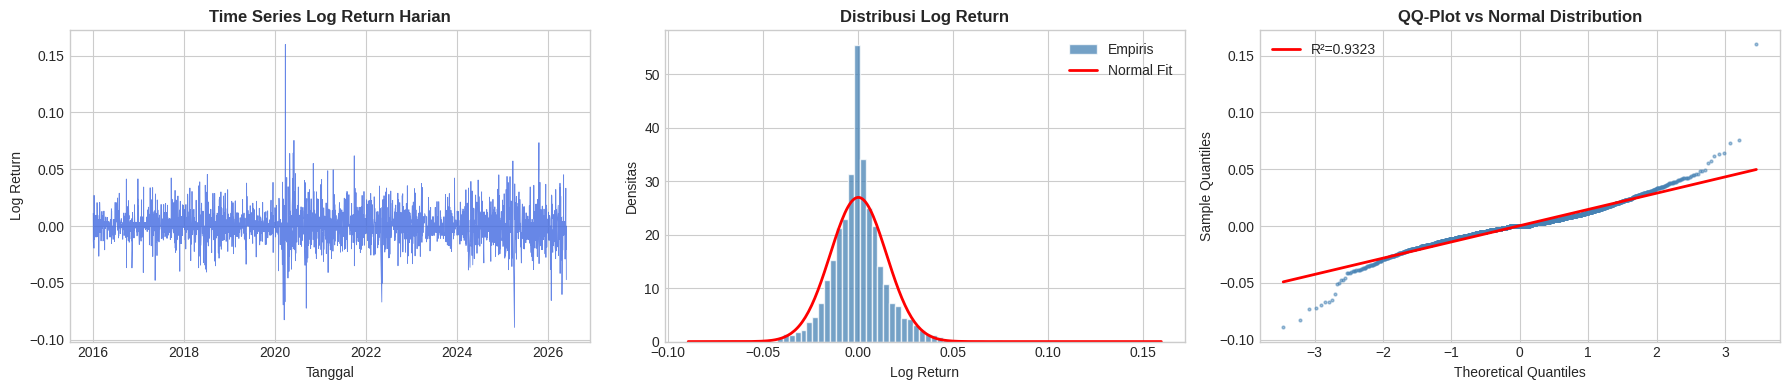

✅ Ekor distribusi berat terlihat pada QQ-Plot → justifikasi penggunaan GARCH.


In [5]:
# ══════════════════════════════════════════════════════════════
# 2b. Visualisasi Return + QQ-Plot
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# --- Time series ---
axes[0].plot(log_returns, color='royalblue', linewidth=0.6, alpha=0.8)
axes[0].set_title('Time Series Log Return Harian', fontweight='bold')
axes[0].set_xlabel('Tanggal'); axes[0].set_ylabel('Log Return')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# --- Histogram + KDE ---
from scipy.stats import norm as norm_dist
axes[1].hist(log_returns, bins=80, color='steelblue', edgecolor='white',
             alpha=0.75, density=True, label='Empiris')
mu_r, std_r = float(log_returns.mean()), float(log_returns.std())
x_r = np.linspace(log_returns.min(), log_returns.max(), 300)
axes[1].plot(x_r, norm_dist.pdf(x_r, mu_r, std_r), 'r-', lw=2, label='Normal Fit')
axes[1].set_title('Distribusi Log Return', fontweight='bold')
axes[1].set_xlabel('Log Return'); axes[1].set_ylabel('Densitas')
axes[1].legend()

# --- QQ-Plot ---
(osm, osr), (slope, intercept, r) = probplot(log_returns, dist='norm')
axes[2].scatter(osm, osr, s=4, alpha=0.5, color='steelblue')
axes[2].plot(osm, slope * np.array(osm) + intercept, 'r-', lw=2, label=f'R²={r**2:.4f}')
axes[2].set_title('QQ-Plot vs Normal Distribution', fontweight='bold')
axes[2].set_xlabel('Theoretical Quantiles'); axes[2].set_ylabel('Sample Quantiles')
axes[2].legend()

plt.tight_layout()
plt.savefig('fig_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Ekor distribusi berat terlihat pada QQ-Plot → justifikasi penggunaan GARCH.')


In [6]:
# ══════════════════════════════════════════════════════════════
# 2c. Uji Stasioneritas — Augmented Dickey-Fuller
# ══════════════════════════════════════════════════════════════
print('='*60)
print('UJI STASIONERITAS — Augmented Dickey-Fuller (ADF) Test')
print('='*60)
adf_result  = adfuller(log_returns, autolag='AIC')
adf_stat    = adf_result[0]
adf_pvalue  = adf_result[1]
adf_lags    = adf_result[2]
adf_nobs    = adf_result[3]
print(f'  ADF Statistic : {adf_stat:.6f}')
print(f'  p-value       : {adf_pvalue:.6f}')
print(f'  Lags Used     : {adf_lags}')
print(f'  N Obs         : {adf_nobs}')
print('  Critical Values:')
for key, val in adf_result[4].items():
    print(f'    {key}: {val:.4f}')
if adf_pvalue < 0.05:
    print('\n✅ Kesimpulan: Data STASIONER (p < 0.05) → Prasyarat ARIMA terpenuhi.')
else:
    print('\n⚠️  Data NON-STASIONER → Perlu differencing.')

# ── Uji ARCH-LM ───────────────────────────────────────────────────────────
print('\n' + '='*60)
print("UJI EFEK ARCH — Engle's ARCH-LM Test")
print('='*60)
arch_stat, arch_pvalue, _, _ = het_arch(log_returns, nlags=5)
print(f'  LM Statistic : {arch_stat:.6f}')
print(f'  p-value      : {arch_pvalue:.6f}')
if arch_pvalue < 0.05:
    print('\n✅ Terdapat efek ARCH (heteroskedastisitas) → GARCH valid secara akademis.')
else:
    print('\n⚠️  Tidak terdeteksi efek ARCH.')


UJI STASIONERITAS — Augmented Dickey-Fuller (ADF) Test
  ADF Statistic : -39.126832
  p-value       : 0.000000
  Lags Used     : 1
  N Obs         : 2559
  Critical Values:
    1%: -3.4329
    5%: -2.8627
    10%: -2.5674

✅ Kesimpulan: Data STASIONER (p < 0.05) → Prasyarat ARIMA terpenuhi.

UJI EFEK ARCH — Engle's ARCH-LM Test
  LM Statistic : 129.509490
  p-value      : 0.000000

✅ Terdapat efek ARCH (heteroskedastisitas) → GARCH valid secara akademis.


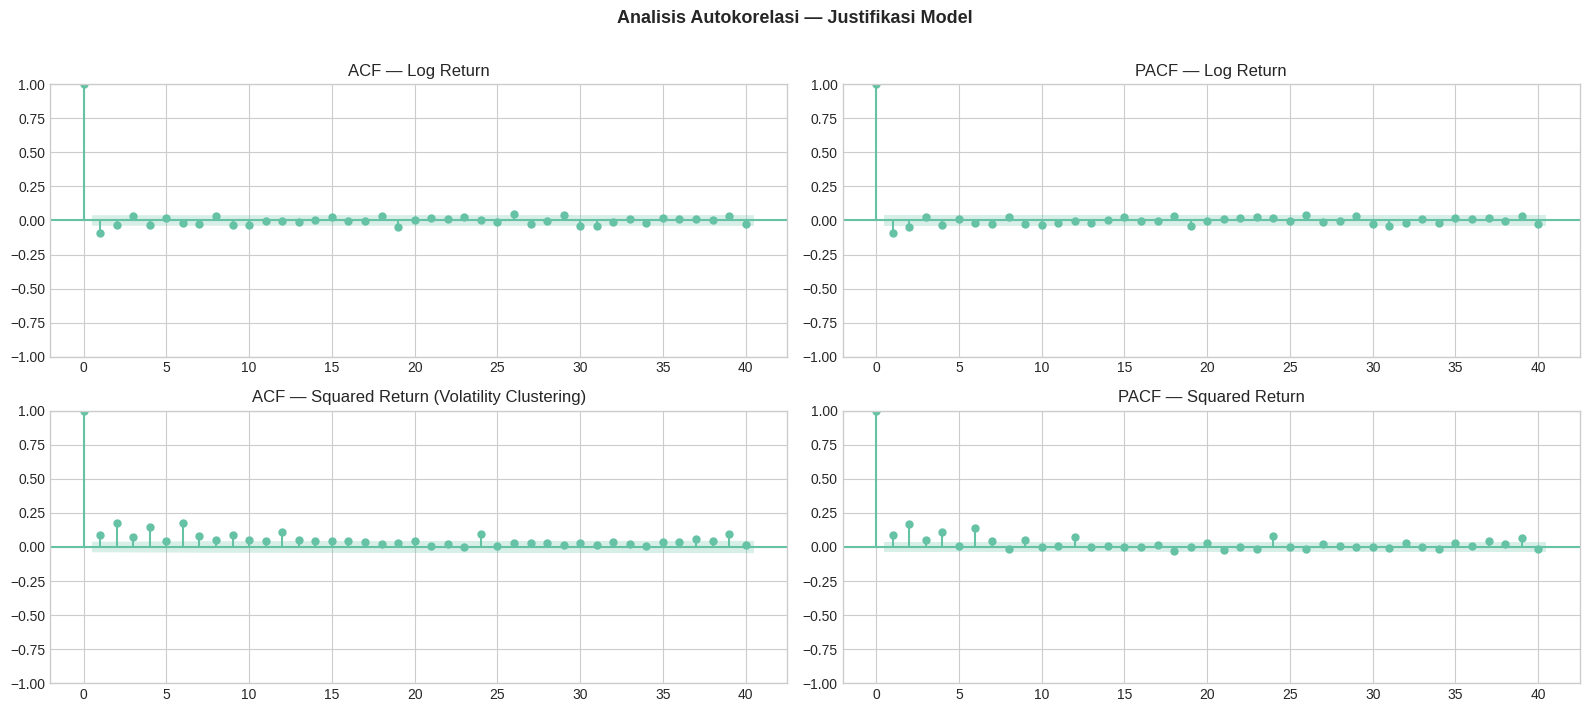

✅ ACF squared return menunjukkan volatility clustering → mendukung GARCH.


In [7]:
# ══════════════════════════════════════════════════════════════
# 2d. ACF & PACF Log Return + Squared Return
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 7))

plot_acf(log_returns,         lags=40, ax=axes[0, 0], title='ACF — Log Return')
plot_pacf(log_returns,        lags=40, ax=axes[0, 1], title='PACF — Log Return', method='ywm')
plot_acf(log_returns**2,      lags=40, ax=axes[1, 0], title='ACF — Squared Return (Volatility Clustering)')
plot_pacf(log_returns**2,     lags=40, ax=axes[1, 1], title='PACF — Squared Return', method='ywm')

plt.suptitle('Analisis Autokorelasi — Justifikasi Model', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ ACF squared return menunjukkan volatility clustering → mendukung GARCH.')


PEMBAGIAN DATA
  Total data  : 2561 hari
  Train (80%) : 2048 hari  [2016-01-05 — 2024-03-26]
  Test  (20%) : 513 hari  [2024-03-27  — 2026-05-29]


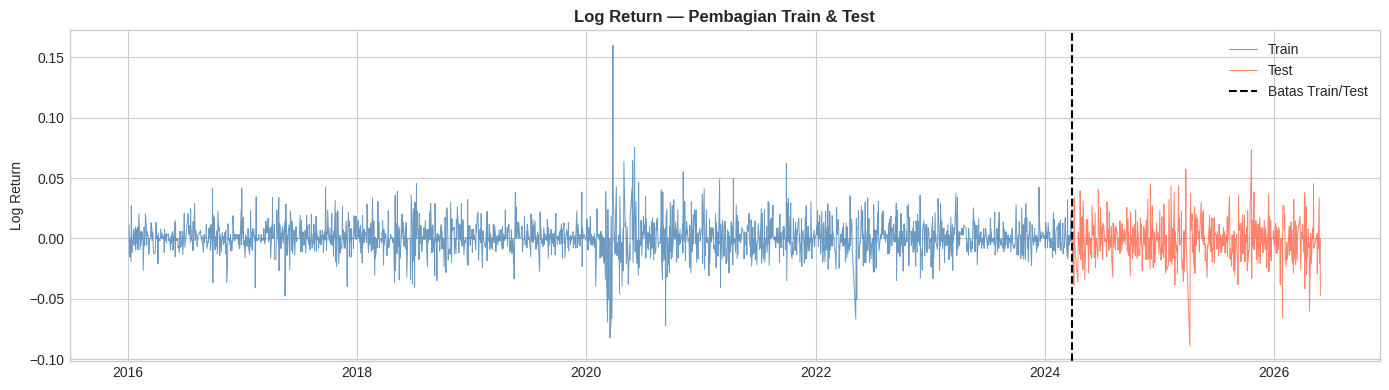

In [8]:
# ══════════════════════════════════════════════════════════════
# 2e. Train-Test Split
# ══════════════════════════════════════════════════════════════
n_total      = len(log_returns)
n_train      = int(n_total * TRAIN_RATIO)
n_test       = n_total - n_train

train_returns = log_returns.iloc[:n_train]
test_returns  = log_returns.iloc[n_train:]

print('='*55)
print('PEMBAGIAN DATA')
print('='*55)
print(f'  Total data  : {n_total} hari')
print(f'  Train (80%) : {n_train} hari  [{train_returns.index[0].date()} — {train_returns.index[-1].date()}]')
print(f'  Test  (20%) : {n_test} hari  [{test_returns.index[0].date()}  — {test_returns.index[-1].date()}]')

# Visual split line
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_returns.index, train_returns, color='steelblue', linewidth=0.7, label='Train', alpha=0.8)
ax.plot(test_returns.index,  test_returns,  color='tomato',    linewidth=0.7, label='Test',  alpha=0.8)
ax.axvline(test_returns.index[0], color='black', linestyle='--', lw=1.5, label='Batas Train/Test')
ax.set_title('Log Return — Pembagian Train & Test', fontweight='bold')
ax.set_ylabel('Log Return'); ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('fig_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Tahap Model Development & Forecasting
### 3A — Model Baseline: ARIMA

In [9]:
# ══════════════════════════════════════════════════════════════
# 3A-1. Auto-search ARIMA order
# ══════════════════════════════════════════════════════════════
print('Mencari parameter ARIMA terbaik (auto_arima)...')
arima_auto = pm.auto_arima(
    train_returns,
    start_p=0, start_q=0,
    max_p=5,   max_q=5,
    d=0,                        # sudah stasioner
    information_criterion='aic',
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True
)
ARIMA_ORDER = arima_auto.order
print(f'\n✅ Best model: ARIMA{ARIMA_ORDER}')
print(arima_auto.summary())


Mencari parameter ARIMA terbaik (auto_arima)...
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-11647.315, Time=0.95 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-11660.218, Time=1.49 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-11661.053, Time=3.52 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-11643.877, Time=0.14 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-11659.595, Time=0.44 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=-11659.958, Time=1.03 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-11660.338, Time=2.64 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-11656.477, Time=0.41 sec

Best model:  ARIMA(0,0,1)(0,0,0)[0] intercept
Total fit time: 10.644 seconds

✅ Best model: ARIMA(0, 0, 1)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2048
Model:               SARIMAX(0, 0, 1)   Log Likelihood                5833.526
Date:               

In [10]:
# ══════════════════════════════════════════════════════════════
# 3A-2. ARIMA One-step-ahead Rolling Forecast (optimasi kecepatan)
#
# PERBAIKAN: Gunakan statsmodels ARIMA.apply() untuk re-fit cepat
# tanpa harus memanggil pm.ARIMA setiap iterasi (jauh lebih cepat).
# ══════════════════════════════════════════════════════════════
print(f'Rolling one-step-ahead forecast ARIMA{ARIMA_ORDER} pada test set...')
print(f'(n_test = {n_test} iterasi)')

train_arr = train_returns.values.astype(float)
test_arr  = test_returns.values.astype(float)

arima_mu_forecasts = np.zeros(n_test)

# Fit awal pada training
arima_fit = ARIMA_sm(train_arr, order=ARIMA_ORDER).fit()

history = train_arr.copy()

for i in range(n_test):
    if i == 0:
        fc = arima_fit.forecast(steps=1)[0]
    else:
        # apply() jauh lebih cepat daripada re-fit penuh
        try:
            arima_fit = arima_fit.apply(endog=history, refit=False)
            fc = arima_fit.forecast(steps=1)[0]
        except Exception:
            arima_fit = ARIMA_sm(history, order=ARIMA_ORDER).fit(disp=False)
            fc = arima_fit.forecast(steps=1)[0]
    arima_mu_forecasts[i] = fc
    history = np.append(history, test_arr[i])
    if (i + 1) % 100 == 0:
        print(f'  Progress: {i+1}/{n_test}')

# Residual std dari training (sigma konstan ARIMA)
arima_sigma_const = float(np.std(arima_fit.resid))

print(f'\n✅ ARIMA rolling forecast selesai.')
print(f'   Sigma residual (konstan) : {arima_sigma_const:.6f}')
print(f'   Mean µ forecast          : {arima_mu_forecasts.mean():.6f}')
print(f'   Std  µ forecast          : {arima_mu_forecasts.std():.6f}')


Rolling one-step-ahead forecast ARIMA(0, 0, 1) pada test set...
(n_test = 513 iterasi)
  Progress: 100/513
  Progress: 200/513
  Progress: 300/513
  Progress: 400/513
  Progress: 500/513

✅ ARIMA rolling forecast selesai.
   Sigma residual (konstan) : 0.014688
   Mean µ forecast          : 0.000874
   Std  µ forecast          : 0.001482


### 3B — Model Usulan: GARCH(1,1) + LSTM

In [11]:
# ══════════════════════════════════════════════════════════════
# 3B-1. GARCH(1,1) — Fit HANYA pada train set
#
# PERBAIKAN KRITIS: Sebelumnya GARCH di-fit pada FULL data (train+test)
# lalu conditional variance diambil untuk seluruh periode.
# Ini adalah DATA LEAKAGE karena model "tahu" volatilitas masa depan.
#
# Solusi: Fit GARCH pada train, lalu lakukan walk-forward forecast
# untuk mendapatkan kondisional variance 1-hari-ke-depan secara proper.
# ══════════════════════════════════════════════════════════════
print('Fitting GARCH(1,1) pada data TRAINING saja...')

train_scaled = train_returns * 100   # skala x100 stabilitas numerik

garch_spec  = arch_model(train_scaled, vol='Garch', p=1, q=1,
                         mean='Constant', dist='normal')
garch_fit   = garch_spec.fit(disp='off', show_warning=False)

print(garch_fit.summary())

# Parameter GARCH
garch_params = garch_fit.params
omega = float(garch_params['omega'])
alpha1 = float(garch_params['alpha[1]'])
beta1  = float(garch_params['beta[1]'])
print(f'\nParameter GARCH(1,1):')
print(f'  omega  (ω) = {omega:.6f}')
print(f'  alpha  (α) = {alpha1:.6f}')
print(f'  beta   (β) = {beta1:.6f}')
print(f'  α + β      = {alpha1 + beta1:.6f}  (< 1 → stasioner)')
if alpha1 + beta1 >= 1:
    print('  ⚠️  α + β ≥ 1: proses IGARCH, volatilitas tidak mean-reverting!')


Fitting GARCH(1,1) pada data TRAINING saja...
                     Constant Mean - GARCH Model Results                      
Dep. Variable:             Log_Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3412.51
Distribution:                  Normal   AIC:                           6833.03
Method:            Maximum Likelihood   BIC:                           6855.53
                                        No. Observations:                 2048
Date:                Sun, May 31 2026   Df Residuals:                     2047
Time:                        08:58:28   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0

In [12]:
# ══════════════════════════════════════════════════════════════
# 3B-2. GARCH Walk-forward Forecast untuk Feature LSTM
#
# Dapatkan conditional variance in-sample (train) dan
# 1-hari-ke-depan (test) secara proper tanpa leakage.
# ══════════════════════════════════════════════════════════════

# --- Conditional variance in-sample (train) ---
cond_vol_train = garch_fit.conditional_volatility / 100   # kembalikan ke skala asli
cond_var_train = cond_vol_train ** 2

print(f'In-sample cond_var shape : {cond_var_train.shape}')

# --- Walk-forward GARCH forecast untuk test set ---
# Inisialisasi: ambil sigma_t dan epsilon_t terakhir dari training
last_sigma2 = float(cond_vol_train.iloc[-1]) ** 2   # σ²_{T}
last_eps2   = float(train_returns.iloc[-1]) ** 2    # ε²_{T} = r²_{T} (residual ≈ return untuk mean konstan)

all_returns = np.concatenate([train_returns.values, test_returns.values])

cond_var_test_forecast = np.zeros(n_test)   # σ²_{t+1|t} (1-step-ahead)
current_sigma2 = last_sigma2
current_eps2   = last_eps2

for i in range(n_test):
    # Forecast σ²_{t+1} menggunakan GARCH rekursi
    next_sigma2 = (omega/10000) + alpha1 * current_eps2 + beta1 * current_sigma2
    cond_var_test_forecast[i] = next_sigma2

    # Update dengan data aktual (walk-forward proper)
    actual_r   = float(test_returns.iloc[i])
    current_eps2   = actual_r ** 2      # ε²_t = r²_t (di bawah mean-konstan kecil)
    current_sigma2 = next_sigma2

cond_sigma_test = np.sqrt(np.abs(cond_var_test_forecast))

print(f'GARCH Walk-Forward Test Forecast:')
print(f'  Min σ : {cond_sigma_test.min():.6f}')
print(f'  Max σ : {cond_sigma_test.max():.6f}')
print(f'  Mean σ: {cond_sigma_test.mean():.6f}')


In-sample cond_var shape : (2048,)
GARCH Walk-Forward Test Forecast:
  Min σ : 0.010052
  Max σ : 0.035484
  Mean σ: 0.015395


In [13]:
# ══════════════════════════════════════════════════════════════
# 3B-3. Feature Engineering untuk LSTM
#
# Input  : [return_t, cond_var_t]  → window WINDOW_SIZE hari
# Target : cond_var_{t+1}          → volatilitas 1 hari ke depan
# ══════════════════════════════════════════════════════════════

# Gabungkan feature (HANYA dari data train — no leakage)
df_feat = pd.DataFrame({
    'return'  : train_returns.values,
    'cond_var': cond_var_train.values
}, index=train_returns.index)

# Target: cond_var shift(-1)
df_feat['target'] = df_feat['cond_var'].shift(-1)
df_feat.dropna(inplace=True)

feature_cols = ['return', 'cond_var']
target_col   = 'target'

# ── Scaling (fit HANYA pada train, transform juga test nanti) ─────────────
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_all_scaled = scaler_X.fit_transform(df_feat[feature_cols])
y_all_scaled = scaler_y.fit_transform(df_feat[[target_col]])

print(f'Feature matrix shape : {X_all_scaled.shape}')
print(f'Scaler X range (fit) : [{scaler_X.data_min_}, {scaler_X.data_max_}]')

def create_sequences(X, y, window_size):
    """Sliding window untuk LSTM input."""
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i : i + window_size])
        ys.append(y[i + window_size])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_all_scaled, y_all_scaled, WINDOW_SIZE)
print(f'X_train_seq shape : {X_train_seq.shape}  (samples, timesteps, features)')
print(f'y_train_seq shape : {y_train_seq.shape}')


Feature matrix shape : (2047, 2)
Scaler X range (fit) : [[-8.24435474e-02  8.03153455e-05], [0.15984866 0.00376657]]
X_train_seq shape : (2017, 30, 2)  (samples, timesteps, features)
y_train_seq shape : (2017, 1)


In [14]:
# ══════════════════════════════════════════════════════════════
# 3B-4. Arsitektur & Training LSTM
# ══════════════════════════════════════════════════════════════
n_features = X_train_seq.shape[2]

tf.keras.backend.clear_session()
lstm_model = Sequential([
    LSTM(64, return_sequences=True,
         input_shape=(WINDOW_SIZE, n_features),
         kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    Dropout(0.2),
    LSTM(32, return_sequences=True),
    Dropout(0.2),
    LSTM(16, return_sequences=False),
    Dropout(0.1),
    Dense(16, activation='relu',
          kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    Dense(1, activation='relu')    # volatilitas selalu positif → ReLU output
], name='GARCH_LSTM_VaR')

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)
lstm_model.summary()

# ── Callbacks ─────────────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=1
)

# ── Training ──────────────────────────────────────────────────────────────
history_lstm = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=150,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print('\n✅ Training LSTM selesai.')


Model: "GARCH_LSTM_VaR"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,993 (128.88 KB)

 Trainable params: 32,993 (128.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - loss: 0.0042 - mae: 0.0243 - val_loss: 0.0019 - val_mae: 0.0187 - learning_rate: 0.0010
Epoch 2/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.0035 - mae: 0.0224 - val_loss: 0.0014 - val_mae: 0.0122 - learning_rate: 0.0010
Epoch 3/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0029 - mae: 0.0209 - val_loss: 0.0011 - val_mae: 0.0110 - learning_rate: 0.0010
Epoch 4/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0027 - mae: 0.0203 - val_loss: 0.0011 - val_mae: 0.0147 - learning_rate: 0.0010
Epoch 5/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0024 - mae: 0.0196 - val_loss: 9.9414e-04 - val_mae: 0.0135 - learning_rate: 0.0010
Epoch 6/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 0.0025 - mae: 0.0199 - val_loss: 0.0010 - val_mae: 0.0168 - learning_rate: 0.0010
Epoch 7/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0020 - mae: 0.0185 - val_loss: 7.8900e-04 - val_mae: 0.0097 - learning_rate: 0.001

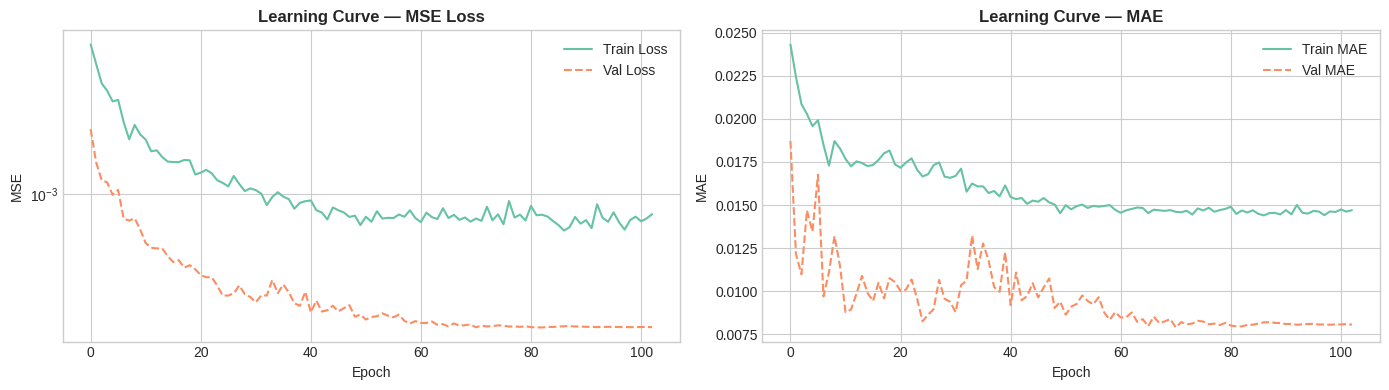

Best epoch   : 83
Best val_loss: 0.000277


In [15]:
# ── Learning Curve ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_lstm.history['loss'],     label='Train Loss', lw=1.5)
axes[0].plot(history_lstm.history['val_loss'], label='Val Loss',   lw=1.5, ls='--')
axes[0].set_title('Learning Curve — MSE Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
axes[0].legend(); axes[0].set_yscale('log')

axes[1].plot(history_lstm.history['mae'],      label='Train MAE', lw=1.5)
axes[1].plot(history_lstm.history['val_mae'],  label='Val MAE',   lw=1.5, ls='--')
axes[1].set_title('Learning Curve — MAE', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

best_epoch = np.argmin(history_lstm.history['val_loss']) + 1
print(f'Best epoch   : {best_epoch}')
print(f'Best val_loss: {min(history_lstm.history["val_loss"]):.6f}')


In [16]:
# ══════════════════════════════════════════════════════════════
# 3B-5. LSTM Forecast pada Test Set
#
# PERBAIKAN: Buat feature test menggunakan GARCH walk-forward
# yang sudah di-compute sebelumnya (bukan dari full-data GARCH).
# Gunakan scaler yang di-fit pada train data saja.
# ══════════════════════════════════════════════════════════════

# Feature test: [return_t, cond_var_t] dari walk-forward GARCH
# Note: cond_var_test_forecast[i] = σ²_{t+1|t} (forecast besok)
# Untuk input LSTM, kita butuh σ²_t (hari ini)
# Kita bisa gunakan σ²_{t|t-1} yang sudah dihitung sebelumnya

# Reconstruct σ²_t untuk test set (kondisi hari ini, bukan besok)
cond_var_test_current = np.zeros(n_test)
current_sigma2 = float(cond_vol_train.iloc[-1]) ** 2
current_eps2   = float(train_returns.iloc[-1]) ** 2

for i in range(n_test):
    cond_var_test_current[i] = current_sigma2
    actual_r       = float(test_returns.iloc[i])
    next_sigma2    = (omega/10000) + alpha1 * current_eps2 + beta1 * current_sigma2
    current_eps2   = actual_r ** 2
    current_sigma2 = next_sigma2

# Feature matrix test
X_test_raw = np.column_stack([
    test_returns.values,
    cond_var_test_current
])
X_test_scaled = scaler_X.transform(X_test_raw)

# Dummy target (tidak dipakai, hanya untuk create_sequences compatibility)
y_test_dummy = np.zeros((n_test, 1))

# Gabungkan ekor train + test untuk windowing
# (LSTM butuh WINDOW_SIZE hari sebelumnya)
X_full_scaled = np.vstack([X_all_scaled, X_test_scaled])
y_full_dummy  = np.vstack([y_all_scaled,
                           np.zeros((n_test, 1))])

X_full_seq, _ = create_sequences(X_full_scaled, y_full_dummy, WINDOW_SIZE)

# Ambil hanya porsi test
X_test_seq_proper = X_full_seq[len(X_train_seq):]
print(f'X_test_seq_proper shape : {X_test_seq_proper.shape}')

# Prediksi
lstm_pred_scaled = lstm_model.predict(X_test_seq_proper, verbose=0)
lstm_pred_var    = scaler_y.inverse_transform(lstm_pred_scaled).flatten()
lstm_pred_var    = np.abs(lstm_pred_var)      # pastikan positif
lstm_pred_sigma  = np.sqrt(lstm_pred_var)     # σ̂_{t+1|t}

print(f'\nPrediksi σ LSTM:')
print(f'  Min  : {lstm_pred_sigma.min():.6f}')
print(f'  Max  : {lstm_pred_sigma.max():.6f}')
print(f'  Mean : {lstm_pred_sigma.mean():.6f}')
print(f'  Std  : {lstm_pred_sigma.std():.6f}')


X_test_seq_proper shape : (513, 30, 2)

Prediksi σ LSTM:
  Min  : 0.011493
  Max  : 0.032087
  Mean : 0.014937
  Std  : 0.002862


## 4. Tahap Kalkulasi Value at Risk (VaR)

In [17]:
# ══════════════════════════════════════════════════════════════
# 4. Hitung VaR
#
# Formula VaR parametrik: VaR_t = µ_t + z_α × σ_t
#
# PERBAIKAN KRITIS:
#   - VaR ARIMA   : µ dari ARIMA forecast + σ konstan residual
#   - VaR GARCH-LSTM: µ dari ARIMA forecast + σ dari LSTM forecast
#   Keduanya menggunakan µ yang SAMA (ARIMA) agar perbandingan
#   mengisolasi kontribusi pemodelan volatilitas saja.
# ══════════════════════════════════════════════════════════════

# Sinkronisasi panjang array
# LSTM kehilangan WINDOW_SIZE sampel di awal karena windowing
offset = len(test_returns) - len(lstm_pred_sigma)
print(f'Offset (WINDOW_SIZE adjusted): {offset}')

actual_returns_sync = test_returns.values[offset:].flatten()
arima_mu_sync       = arima_mu_forecasts[offset:]
test_dates_sync     = test_returns.index[offset:]
n_sync              = len(actual_returns_sync)

assert len(lstm_pred_sigma) == n_sync, "Panjang array tidak sesuai!"

print(f'Jumlah observasi efektif : {n_sync}')
print(f'Periode test efektif     : {test_dates_sync[0].date()} → {test_dates_sync[-1].date()}')
print(f'z_α (95%)               : {Z_ALPHA:.4f}')

# ── VaR ARIMA (σ konstan) ─────────────────────────────────────────────────
VaR_ARIMA = arima_mu_sync + Z_ALPHA * arima_sigma_const

# ── VaR GARCH-LSTM (σ dinamis dari LSTM) ─────────────────────────────────
VaR_GARCH_LSTM = arima_mu_sync + Z_ALPHA * lstm_pred_sigma

print(f'\nStatistik VaR ARIMA:')
print(f'  Mean : {VaR_ARIMA.mean():.6f}')
print(f'  Std  : {VaR_ARIMA.std():.6f}   (0 karena µ saja yg bervariasi)')
print(f'\nStatistik VaR GARCH-LSTM:')
print(f'  Mean : {VaR_GARCH_LSTM.mean():.6f}')
print(f'  Std  : {VaR_GARCH_LSTM.std():.6f}  (dinamis)')


Offset (WINDOW_SIZE adjusted): 0
Jumlah observasi efektif : 513
Periode test efektif     : 2024-03-27 → 2026-05-29
z_α (95%)               : -1.6449

Statistik VaR ARIMA:
  Mean : -0.023286
  Std  : 0.001482   (0 karena µ saja yg bervariasi)

Statistik VaR GARCH-LSTM:
  Mean : -0.023695
  Std  : 0.005028  (dinamis)


## 5. Tahap Evaluasi & Backtesting
### 5A — Hitung Violations

In [18]:
# ══════════════════════════════════════════════════════════════
# 5A. Violations (Exceedances)
# ══════════════════════════════════════════════════════════════
y_true = actual_returns_sync.flatten()
var_arima_arr      = VaR_ARIMA.flatten()
var_garch_lstm_arr = VaR_GARCH_LSTM.flatten()

# Pelanggaran: return aktual < VaR (melampaui batas bawah)
violations_arima     = (y_true < var_arima_arr).astype(int)
violations_garch_lstm = (y_true < var_garch_lstm_arr).astype(int)

n_viol_arima     = int(violations_arima.sum())
n_viol_gl        = int(violations_garch_lstm.sum())
expected_viols   = int(n_sync * ALPHA)

print('='*65)
print('HASIL BACKTESTING — VIOLATIONS')
print('='*65)
print(f'  Total observasi efektif     : {n_sync}')
print(f'  Target violations (α={ALPHA:.2f})  : ~{expected_viols}  ({ALPHA*100:.1f}%)')
print(f'  Violations ARIMA            : {n_viol_arima:3d}  ({n_viol_arima/n_sync*100:.2f}%)')
print(f'  Violations GARCH-LSTM       : {n_viol_gl:3d}  ({n_viol_gl/n_sync*100:.2f}%)')
print()
if n_viol_arima > expected_viols:
    print('  ⚠️  ARIMA: Under-estimates risk (terlalu banyak violations)')
elif n_viol_arima < expected_viols:
    print('  ⚠️  ARIMA: Over-estimates risk (terlalu konservatif)')

if abs(n_viol_gl - expected_viols) <= 3:
    print('  ✅ GARCH-LSTM: Mendekati target violations!')
elif n_viol_gl > expected_viols:
    print('  ⚠️  GARCH-LSTM: Under-estimates risk')
else:
    print('  ⚠️  GARCH-LSTM: Over-estimates risk (terlalu konservatif)')


HASIL BACKTESTING — VIOLATIONS
  Total observasi efektif     : 513
  Target violations (α=0.05)  : ~25  (5.0%)
  Violations ARIMA            :  41  (7.99%)
  Violations GARCH-LSTM       :  36  (7.02%)

  ⚠️  ARIMA: Under-estimates risk (terlalu banyak violations)
  ⚠️  GARCH-LSTM: Under-estimates risk


### 5B — Kupiec POF Test (Proportion of Failures)

In [19]:
# ══════════════════════════════════════════════════════════════
# 5B. Kupiec Proportion of Failures (POF) Test
# H0: Violation rate = α (model valid secara unconditional)
# Reject H0 jika p-value < 0.05
# ══════════════════════════════════════════════════════════════
def kupiec_pof_test(n_obs, n_viol, alpha_level):
    """Kupiec (1995) POF Test."""
    p_hat = n_viol / n_obs
    if n_viol == 0:
        # LR ketika tidak ada violations
        lr = -2 * n_obs * np.log(1 - alpha_level)
    elif n_viol == n_obs:
        lr = -2 * n_obs * np.log(alpha_level)
    else:
        lr = -2 * (
            np.log(((1-alpha_level)**(n_obs-n_viol)) * (alpha_level**n_viol)) -
            np.log(((1-p_hat)**(n_obs-n_viol))       * (p_hat**n_viol))
        )
    p_value = 1 - chi2.cdf(lr, df=1)
    return lr, p_value, p_hat

lr_arima,  pv_arima,  ph_arima  = kupiec_pof_test(n_sync, n_viol_arima, ALPHA)
lr_gl,     pv_gl,     ph_gl     = kupiec_pof_test(n_sync, n_viol_gl,    ALPHA)

print('='*70)
print('KUPIEC POF TEST')
print('H0: Violation rate = α (model calibrated)')
print('='*70)
print(f'{"Model":<22} {"LR Stat":>9} {"p-value":>9} {"Viol%":>7} {"Keputusan"}')
print('-'*70)
for name, lr, pv, ph in [('ARIMA (Baseline)', lr_arima, pv_arima, ph_arima),
                          ('GARCH-LSTM (Proposed)', lr_gl, pv_gl, ph_gl)]:
    status = '✅ Gagal Tolak H0 (Valid)' if pv > 0.05 else '❌ Tolak H0 (Tidak Valid)'
    print(f'{name:<22} {lr:>9.4f} {pv:>9.4f} {ph*100:>6.2f}% {status}')


KUPIEC POF TEST
H0: Violation rate = α (model calibrated)
Model                    LR Stat   p-value   Viol% Keputusan
----------------------------------------------------------------------
ARIMA (Baseline)          8.2490    0.0041   7.99% ❌ Tolak H0 (Tidak Valid)
GARCH-LSTM (Proposed)     3.9276    0.0475   7.02% ❌ Tolak H0 (Tidak Valid)


### 5C — Christoffersen Independence & Conditional Coverage Test

In [20]:
# ══════════════════════════════════════════════════════════════
# 5C. Christoffersen (1998) Independence Test & CC Test
#
# Independence Test: H0: violations tidak berkluster (independen)
# CC Test (Combined): H0: violation rate = α AND independen
# ══════════════════════════════════════════════════════════════
def christoffersen_tests(violations, alpha_level):
    """
    Returns:
      lr_ind, pv_ind  : Independence test
      lr_cc,  pv_cc   : Conditional Coverage (joint) test
      pi01, pi11      : Transition probabilities
    """
    viol = np.array(violations).astype(int)
    n    = len(viol)

    n00 = int(np.sum((viol[:-1] == 0) & (viol[1:] == 0)))
    n01 = int(np.sum((viol[:-1] == 0) & (viol[1:] == 1)))
    n10 = int(np.sum((viol[:-1] == 1) & (viol[1:] == 0)))
    n11 = int(np.sum((viol[:-1] == 1) & (viol[1:] == 1)))

    pi01 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0.0
    pi11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0.0
    pi   = (n01 + n11) / (n00 + n01 + n10 + n11) if n > 0 else 0.0

    eps = 1e-12

    L_ind = (n00 * np.log(max(1 - pi01, eps)) +
             n01 * np.log(max(pi01,     eps)) +
             n10 * np.log(max(1 - pi11, eps)) +
             n11 * np.log(max(pi11,     eps)))

    L_unc = ((n00 + n10) * np.log(max(1 - pi, eps)) +
             (n01 + n11) * np.log(max(pi,     eps)))

    lr_ind = -2 * (L_unc - L_ind)
    pv_ind  = 1 - chi2.cdf(max(lr_ind, 0), df=1)

    # POF component (untuk CC)
    n_viol = n01 + n11
    lr_pof, _, _ = kupiec_pof_test(n, n_viol, alpha_level)

    lr_cc  = max(lr_pof, 0) + max(lr_ind, 0)
    pv_cc  = 1 - chi2.cdf(lr_cc, df=2)

    return lr_ind, pv_ind, lr_cc, pv_cc, pi01, pi11, n00, n01, n10, n11

(lr_ind_a, pv_ind_a, lr_cc_a, pv_cc_a,
 pi01_a, pi11_a, n00_a, n01_a, n10_a, n11_a) = christoffersen_tests(violations_arima, ALPHA)

(lr_ind_g, pv_ind_g, lr_cc_g, pv_cc_g,
 pi01_g, pi11_g, n00_g, n01_g, n10_g, n11_g) = christoffersen_tests(violations_garch_lstm, ALPHA)

print('='*75)
print('CHRISTOFFERSEN INDEPENDENCE TEST')
print('H0: Violations INDEPENDEN (tidak berkluster)')
print('='*75)
print(f'{"Model":<22} {"LR":>8} {"p-value":>9} {"π01":>7} {"π11":>7} {"Keputusan"}')
print('-'*75)
for name, lr, pv, pi01, pi11 in [
    ('ARIMA',      lr_ind_a, pv_ind_a, pi01_a, pi11_a),
    ('GARCH-LSTM', lr_ind_g, pv_ind_g, pi01_g, pi11_g)]:
    status = '✅ Independen' if pv > 0.05 else '❌ Kluster'
    print(f'{name:<22} {lr:>8.4f} {pv:>9.4f} {pi01:>7.4f} {pi11:>7.4f} {status}')

print()
print('='*75)
print('CHRISTOFFERSEN CONDITIONAL COVERAGE (CC) TEST')
print('H0: Violation rate = α AND independen (joint test)')
print('='*75)
print(f'{"Model":<22} {"LR CC":>8} {"p-value":>9} {"Keputusan"}')
print('-'*75)
for name, lr, pv in [('ARIMA', lr_cc_a, pv_cc_a), ('GARCH-LSTM', lr_cc_g, pv_cc_g)]:
    status = '✅ Valid (CC)' if pv > 0.05 else '❌ Tidak Valid (CC)'
    print(f'{name:<22} {lr:>8.4f} {pv:>9.4f} {status}')

print()
print('Transition matrix ARIMA:')
print(f'  P(viol→no-viol) π10 = {1-pi11_a:.4f},  P(no-viol→viol) π01 = {pi01_a:.4f}')
print(f'  P(viol→viol)    π11 = {pi11_a:.4f}  ← clustering indicator')


CHRISTOFFERSEN INDEPENDENCE TEST
H0: Violations INDEPENDEN (tidak berkluster)
Model                        LR   p-value     π01     π11 Keputusan
---------------------------------------------------------------------------
ARIMA                    0.6025    0.4376  0.0826  0.0500 ✅ Independen
GARCH-LSTM               0.1056    0.7452  0.0713  0.0571 ✅ Independen

CHRISTOFFERSEN CONDITIONAL COVERAGE (CC) TEST
H0: Violation rate = α AND independen (joint test)
Model                     LR CC   p-value Keputusan
---------------------------------------------------------------------------
ARIMA                    8.8515    0.0120 ❌ Tidak Valid (CC)
GARCH-LSTM               4.0332    0.1331 ✅ Valid (CC)

Transition matrix ARIMA:
  P(viol→no-viol) π10 = 0.9500,  P(no-viol→viol) π01 = 0.0826
  P(viol→viol)    π11 = 0.0500  ← clustering indicator


### 5D — Rangkuman Evaluasi Lengkap

In [21]:
# ══════════════════════════════════════════════════════════════
# 5D. Tabel Ringkasan untuk Jurnal
# ══════════════════════════════════════════════════════════════
import pandas as pd

def validity_icon(pv):
    return '✅ Valid' if pv > 0.05 else '❌ Tidak Valid'

summary = pd.DataFrame({
    'Metric': [
        'N Observasi Test', 'Target Violations (5%)', 'N Violations Aktual',
        'Violation Rate (%)',
        'Kupiec LR Stat', 'Kupiec p-value', 'Kupiec Valid',
        'Independence LR', 'Independence p-value', 'Independence Valid',
        'CC LR Stat', 'CC p-value', 'CC Valid (Joint)',
        'Mean VaR', 'Std VaR'
    ],
    'ARIMA (Baseline)': [
        n_sync, expected_viols, n_viol_arima,
        f'{n_viol_arima/n_sync*100:.2f}%',
        f'{lr_arima:.4f}', f'{pv_arima:.4f}', validity_icon(pv_arima),
        f'{lr_ind_a:.4f}', f'{pv_ind_a:.4f}', validity_icon(pv_ind_a),
        f'{lr_cc_a:.4f}', f'{pv_cc_a:.4f}', validity_icon(pv_cc_a),
        f'{VaR_ARIMA.mean():.6f}', f'{VaR_ARIMA.std():.6f}'
    ],
    'GARCH-LSTM (Proposed)': [
        n_sync, expected_viols, n_viol_gl,
        f'{n_viol_gl/n_sync*100:.2f}%',
        f'{lr_gl:.4f}', f'{pv_gl:.4f}', validity_icon(pv_gl),
        f'{lr_ind_g:.4f}', f'{pv_ind_g:.4f}', validity_icon(pv_ind_g),
        f'{lr_cc_g:.4f}', f'{pv_cc_g:.4f}', validity_icon(pv_cc_g),
        f'{VaR_GARCH_LSTM.mean():.6f}', f'{VaR_GARCH_LSTM.std():.6f}'
    ]
})

print('='*75)
print('RANGKUMAN HASIL EVALUASI MODEL — SIAP UNTUK JURNAL')
print('='*75)
pd.set_option('display.max_colwidth', 30)
display(summary)

# Export ke CSV
summary.to_csv('evaluation_summary.csv', index=False)
print('\n✅ Tabel evaluasi disimpan: evaluation_summary.csv')


RANGKUMAN HASIL EVALUASI MODEL — SIAP UNTUK JURNAL


,Metric,ARIMA (Baseline),GARCH-LSTM (Proposed)
0,N Observasi Test,513,513
1,Target Violations (5%),25,25
2,N Violations Aktual,41,36
3,Violation Rate (%),7.99%,7.02%
4,Kupiec LR Stat,8.2490,3.9276
5,Kupiec p-value,0.0041,0.0475
6,Kupiec Valid,❌ Tidak Valid,❌ Tidak Valid
7,Independence LR,0.6025,0.1056
8,Independence p-value,0.4376,0.7452
9,Independence Valid,✅ Valid,✅ Valid



✅ Tabel evaluasi disimpan: evaluation_summary.csv


## 6. Visualisasi Komprehensif untuk Jurnal

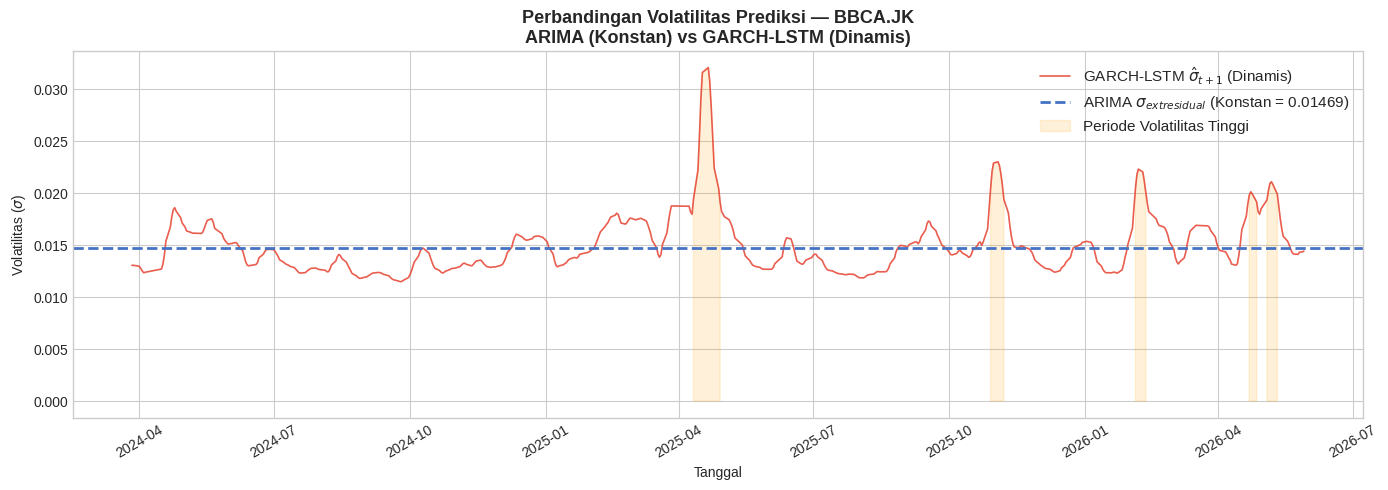

✅ Plot 1 disimpan: fig1_volatility_comparison.png


In [22]:
# ══════════════════════════════════════════════════════════════
# Plot 1 — Volatilitas Prediksi: ARIMA vs GARCH-LSTM
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(test_dates_sync, lstm_pred_sigma,
        label=r'GARCH-LSTM $\hat{\sigma}_{t+1}$ (Dinamis)',
        color=COLORS['garch_lstm'], linewidth=1.2, alpha=0.9)
ax.axhline(y=arima_sigma_const,
           label=f'ARIMA $\sigma_{{\text{{residual}}}}$ (Konstan = {arima_sigma_const:.5f})',
           color=COLORS['arima'], linewidth=2, linestyle='--')

# Shade periode high-volatility
thresh_high = arima_sigma_const * 1.3
high_vol_mask = lstm_pred_sigma > thresh_high
if high_vol_mask.any():
    ax.fill_between(test_dates_sync, 0, lstm_pred_sigma,
                    where=high_vol_mask, alpha=0.15, color='orange', label='Periode Volatilitas Tinggi')

ax.set_title(f'Perbandingan Volatilitas Prediksi — {TICKER}\nARIMA (Konstan) vs GARCH-LSTM (Dinamis)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Tanggal'); ax.set_ylabel(r'Volatilitas ($\sigma$)')
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('fig1_volatility_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print('✅ Plot 1 disimpan: fig1_volatility_comparison.png')


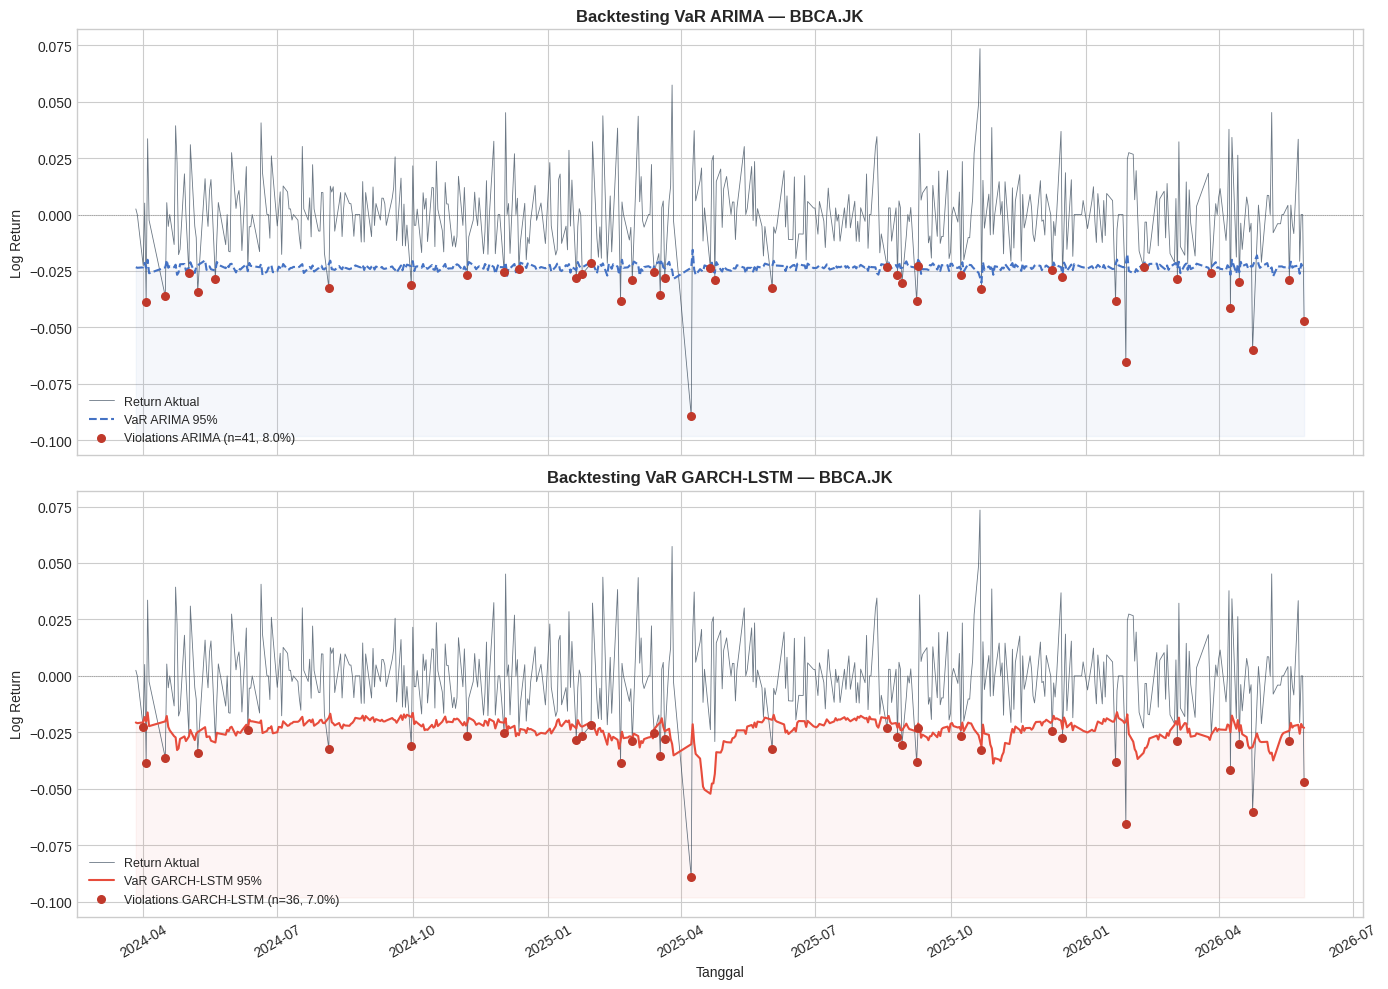

✅ Plot 2 disimpan: fig2_var_backtest.png


In [23]:
# ══════════════════════════════════════════════════════════════
# Plot 2 — VaR vs Return Aktual (Backtesting)
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# ── Panel atas: ARIMA ─────────────────────────────────────────────────────
axes[0].plot(test_dates_sync, y_true,
             color=COLORS['actual'], linewidth=0.6, alpha=0.7, label='Return Aktual')
axes[0].plot(test_dates_sync, var_arima_arr,
             color=COLORS['arima'], linewidth=1.5, linestyle='--',
             label=f'VaR ARIMA {CONFIDENCE*100:.0f}%')
viol_mask_a = y_true < var_arima_arr
axes[0].scatter(test_dates_sync[viol_mask_a], y_true[viol_mask_a],
                color=COLORS['violation'], s=30, zorder=5,
                label=f'Violations ARIMA (n={n_viol_arima}, {n_viol_arima/n_sync*100:.1f}%)')
axes[0].fill_between(test_dates_sync, var_arima_arr, y_true.min() * 1.1,
                     alpha=0.05, color=COLORS['arima'])
axes[0].set_title(f'Backtesting VaR ARIMA — {TICKER}', fontweight='bold')
axes[0].set_ylabel('Log Return')
axes[0].legend(loc='lower left', fontsize=9)
axes[0].axhline(0, color='gray', lw=0.5, ls=':')

# ── Panel bawah: GARCH-LSTM ───────────────────────────────────────────────
axes[1].plot(test_dates_sync, y_true,
             color=COLORS['actual'], linewidth=0.6, alpha=0.7, label='Return Aktual')
axes[1].plot(test_dates_sync, var_garch_lstm_arr,
             color=COLORS['garch_lstm'], linewidth=1.5,
             label=f'VaR GARCH-LSTM {CONFIDENCE*100:.0f}%')
viol_mask_g = y_true < var_garch_lstm_arr
axes[1].scatter(test_dates_sync[viol_mask_g], y_true[viol_mask_g],
                color=COLORS['violation'], s=30, zorder=5,
                label=f'Violations GARCH-LSTM (n={n_viol_gl}, {n_viol_gl/n_sync*100:.1f}%)')
axes[1].fill_between(test_dates_sync, var_garch_lstm_arr, y_true.min() * 1.1,
                     alpha=0.05, color=COLORS['garch_lstm'])
axes[1].set_title(f'Backtesting VaR GARCH-LSTM — {TICKER}', fontweight='bold')
axes[1].set_ylabel('Log Return')
axes[1].set_xlabel('Tanggal')
axes[1].legend(loc='lower left', fontsize=9)
axes[1].axhline(0, color='gray', lw=0.5, ls=':')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[1].get_xticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('fig2_var_backtest.png', dpi=200, bbox_inches='tight')
plt.show()
print('✅ Plot 2 disimpan: fig2_var_backtest.png')


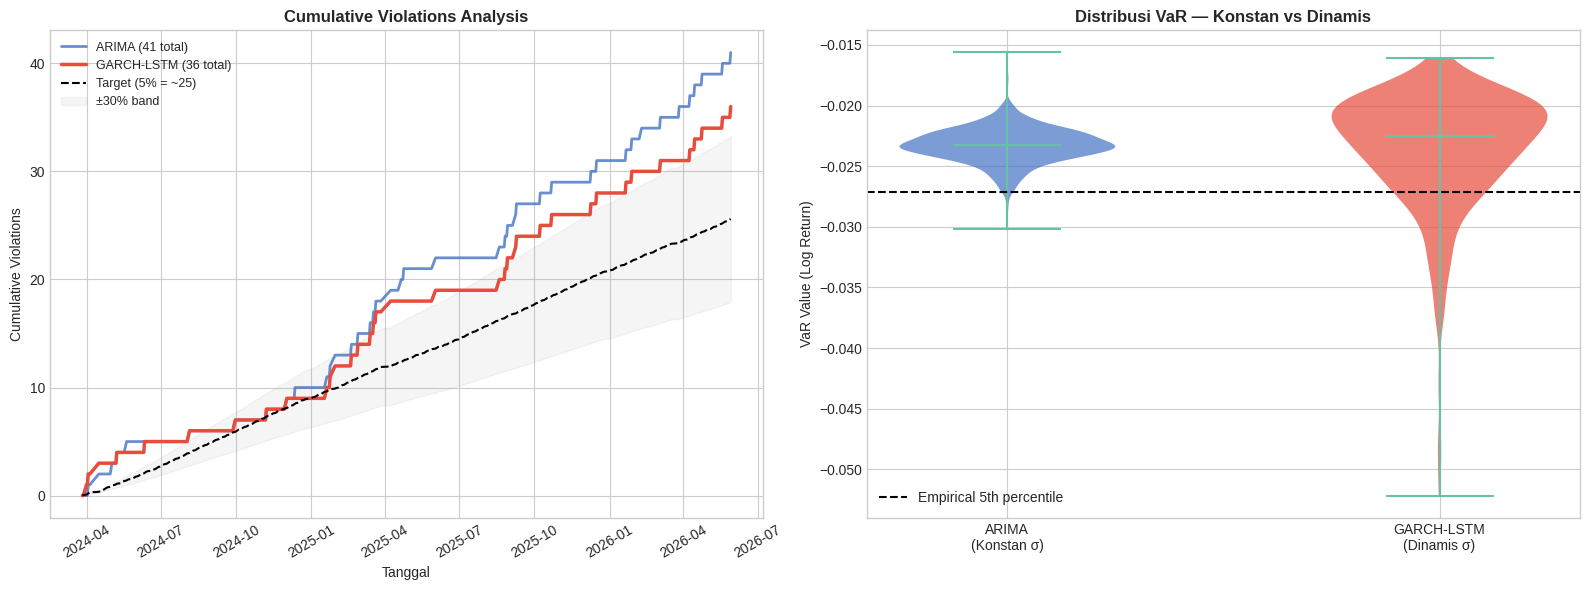

✅ Plot 3 disimpan: fig3_cumulative_violations.png


In [24]:
# ══════════════════════════════════════════════════════════════
# Plot 3 — Cumulative Violations Analysis
# ══════════════════════════════════════════════════════════════
days_elapsed   = np.arange(n_sync)
expected_curve = days_elapsed * ALPHA

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Cumulative violations ─────────────────────────────────────────────────
axes[0].plot(test_dates_sync, np.cumsum(violations_arima),
             color=COLORS['arima'], lw=2, label=f'ARIMA ({n_viol_arima} total)', alpha=0.8)
axes[0].plot(test_dates_sync, np.cumsum(violations_garch_lstm),
             color=COLORS['garch_lstm'], lw=2.5, label=f'GARCH-LSTM ({n_viol_gl} total)')
axes[0].plot(test_dates_sync, expected_curve,
             color='black', lw=1.5, ls='--', label=f'Target (5% = ~{expected_viols})')
axes[0].fill_between(test_dates_sync,
                     expected_curve * 0.7, expected_curve * 1.3,
                     alpha=0.08, color='gray', label='±30% band')
axes[0].set_title('Cumulative Violations Analysis', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Tanggal'); axes[0].set_ylabel('Cumulative Violations')
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[0].get_xticklabels(), rotation=30)

# ── Violin plot distribusi VaR ────────────────────────────────────────────
import matplotlib.patches as mpatches
data_violin = [var_arima_arr, var_garch_lstm_arr]
bp = axes[1].violinplot(data_violin, positions=[1, 2], showmedians=True, showextrema=True)
for pc, color in zip(bp['bodies'], [COLORS['arima'], COLORS['garch_lstm']]):
    pc.set_facecolor(color); pc.set_alpha(0.7)
axes[1].axhline(y=np.percentile(y_true, 5), color='black', ls='--', lw=1.5,
                label='Empirical 5th percentile')
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['ARIMA\n(Konstan σ)', 'GARCH-LSTM\n(Dinamis σ)'])
axes[1].set_title('Distribusi VaR — Konstan vs Dinamis', fontweight='bold', fontsize=12)
axes[1].set_ylabel('VaR Value (Log Return)')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig3_cumulative_violations.png', dpi=200, bbox_inches='tight')
plt.show()
print('✅ Plot 3 disimpan: fig3_cumulative_violations.png')


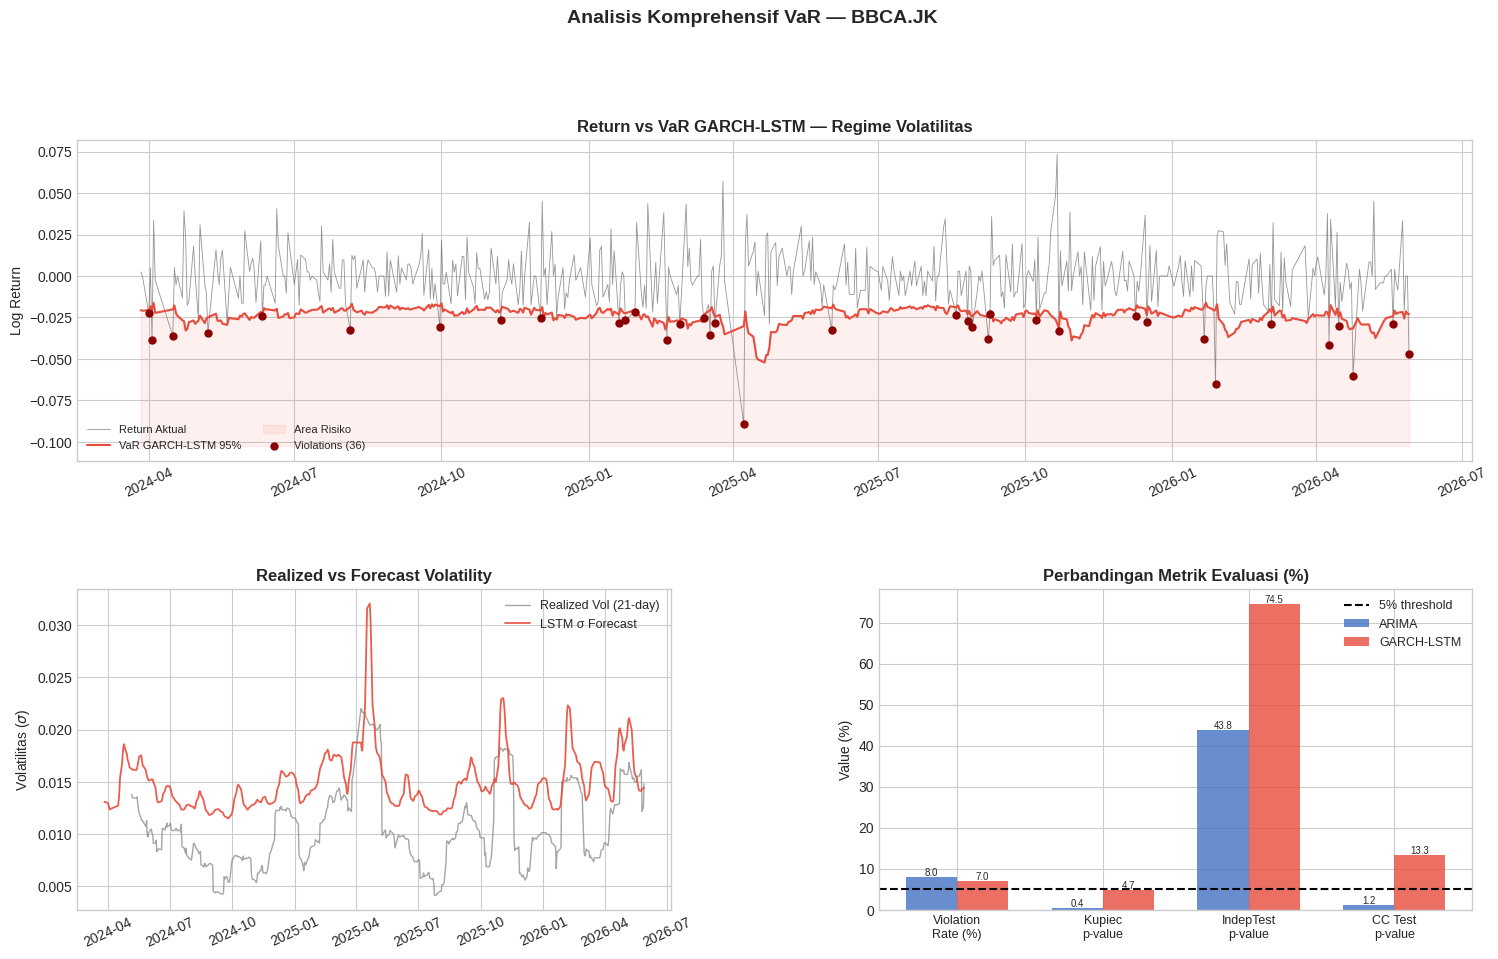

✅ Plot 4 disimpan: fig4_comprehensive_analysis.png


In [25]:
# ══════════════════════════════════════════════════════════════
# Plot 4 — Volatility Regime Analysis & Heatmap Performa
# ══════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── 4a. Return dengan regime warna ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(test_dates_sync, y_true, color='dimgray', lw=0.6, alpha=0.7, label='Return Aktual')
ax1.plot(test_dates_sync, var_garch_lstm_arr, color=COLORS['garch_lstm'],
         lw=1.5, label='VaR GARCH-LSTM 95%')

# Shade area di bawah VaR
ax1.fill_between(test_dates_sync, var_garch_lstm_arr, y_true.min() * 1.15,
                 alpha=0.08, color=COLORS['garch_lstm'], label='Area Risiko')
viol_g = y_true < var_garch_lstm_arr
ax1.scatter(test_dates_sync[viol_g], y_true[viol_g],
            color='darkred', s=25, zorder=6, label=f'Violations ({viol_g.sum()})')
ax1.set_title('Return vs VaR GARCH-LSTM — Regime Volatilitas', fontweight='bold')
ax1.set_ylabel('Log Return')
ax1.legend(loc='lower left', fontsize=8, ncol=2)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax1.get_xticklabels(), rotation=25)

# ── 4b. GARCH-LSTM σ rolling ──────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
roll_vol = pd.Series(np.abs(y_true)).rolling(21).std().values
ax2.plot(test_dates_sync, roll_vol,
         color='gray', lw=1, alpha=0.7, label='Realized Vol (21-day)')
ax2.plot(test_dates_sync, lstm_pred_sigma,
         color=COLORS['garch_lstm'], lw=1.3, alpha=0.9, label='LSTM σ Forecast')
ax2.set_title('Realized vs Forecast Volatility', fontweight='bold')
ax2.set_ylabel(r'Volatilitas ($\sigma$)')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax2.get_xticklabels(), rotation=25)

# ── 4c. Comparison bar chart ──────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
metrics     = ['Violation\nRate (%)', 'Kupiec\np-value', 'IndepTest\np-value', 'CC Test\np-value']
arima_vals  = [n_viol_arima/n_sync*100, pv_arima*100, pv_ind_a*100, pv_cc_a*100]
gl_vals     = [n_viol_gl/n_sync*100,    pv_gl*100,    pv_ind_g*100, pv_cc_g*100]
x_pos = np.arange(len(metrics))
width = 0.35
bars1 = ax3.bar(x_pos - width/2, arima_vals, width, label='ARIMA',
                color=COLORS['arima'], alpha=0.8)
bars2 = ax3.bar(x_pos + width/2, gl_vals,    width, label='GARCH-LSTM',
                color=COLORS['garch_lstm'], alpha=0.8)
ax3.axhline(5,  color='black', ls='--', lw=1.5, label='5% threshold')
ax3.set_xticks(x_pos); ax3.set_xticklabels(metrics, fontsize=9)
ax3.set_ylabel('Value (%)'); ax3.set_title('Perbandingan Metrik Evaluasi (%)', fontweight='bold')
ax3.legend(fontsize=9)
for bar in bars1: ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{bar.get_height():.1f}', ha='center', fontsize=7)
for bar in bars2: ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{bar.get_height():.1f}', ha='center', fontsize=7)

plt.suptitle(f'Analisis Komprehensif VaR — {TICKER}', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('fig4_comprehensive_analysis.png', dpi=200, bbox_inches='tight')
plt.show()
print('✅ Plot 4 disimpan: fig4_comprehensive_analysis.png')


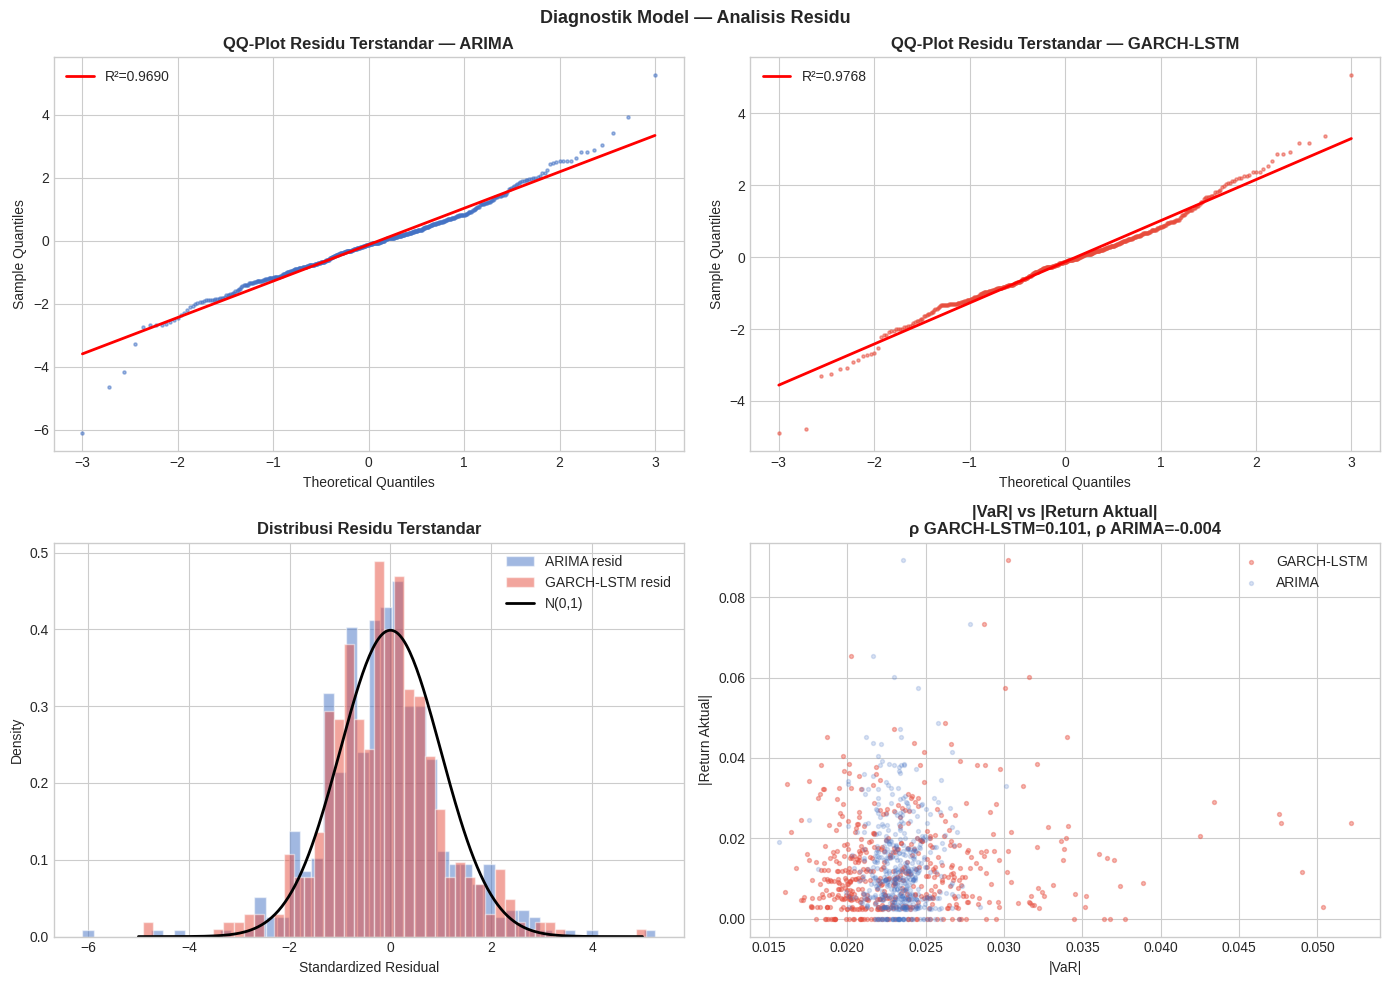


Korelasi |VaR| vs |Return|:
  ARIMA      : -0.0044
  GARCH-LSTM : 0.1011  ← lebih tinggi = lebih responsif terhadap volatilitas aktual


In [26]:
# ══════════════════════════════════════════════════════════════
# Plot 5 — QQ-Plot Residual & Diagnostik GARCH
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── 5a. Standardized residual ARIMA ──────────────────────────────────────
arima_resid_std = (y_true - arima_mu_sync) / arima_sigma_const
(osm_a, osr_a), (s_a, i_a, r_a) = probplot(arima_resid_std, dist='norm')
axes[0, 0].scatter(osm_a, osr_a, s=5, alpha=0.5, color=COLORS['arima'])
axes[0, 0].plot(osm_a, s_a*np.array(osm_a)+i_a, 'r-', lw=2, label=f'R²={r_a**2:.4f}')
axes[0, 0].set_title('QQ-Plot Residu Terstandar — ARIMA', fontweight='bold')
axes[0, 0].set_xlabel('Theoretical Quantiles'); axes[0, 0].set_ylabel('Sample Quantiles')
axes[0, 0].legend()

# ── 5b. Standardized residual GARCH-LSTM ─────────────────────────────────
garch_lstm_resid_std = (y_true - arima_mu_sync) / lstm_pred_sigma
(osm_g, osr_g), (s_g, i_g, r_g) = probplot(garch_lstm_resid_std, dist='norm')
axes[0, 1].scatter(osm_g, osr_g, s=5, alpha=0.5, color=COLORS['garch_lstm'])
axes[0, 1].plot(osm_g, s_g*np.array(osm_g)+i_g, 'r-', lw=2, label=f'R²={r_g**2:.4f}')
axes[0, 1].set_title('QQ-Plot Residu Terstandar — GARCH-LSTM', fontweight='bold')
axes[0, 1].set_xlabel('Theoretical Quantiles'); axes[0, 1].set_ylabel('Sample Quantiles')
axes[0, 1].legend()

# ── 5c. Distribusi residu terstandar ─────────────────────────────────────
x_std = np.linspace(-5, 5, 300)
axes[1, 0].hist(arima_resid_std,      bins=50, density=True,
                color=COLORS['arima'],      alpha=0.5, label='ARIMA resid', edgecolor='white')
axes[1, 0].hist(garch_lstm_resid_std, bins=50, density=True,
                color=COLORS['garch_lstm'], alpha=0.5, label='GARCH-LSTM resid', edgecolor='white')
axes[1, 0].plot(x_std, norm.pdf(x_std), 'k-', lw=2, label='N(0,1)')
axes[1, 0].set_title('Distribusi Residu Terstandar', fontweight='bold')
axes[1, 0].set_xlabel('Standardized Residual')
axes[1, 0].set_ylabel('Density'); axes[1, 0].legend()

# ── 5d. Scatter VaR vs |Return| untuk melihat korelasi ───────────────────
axes[1, 1].scatter(-var_garch_lstm_arr, np.abs(y_true), s=8, alpha=0.4,
                   color=COLORS['garch_lstm'], label='GARCH-LSTM')
axes[1, 1].scatter(-var_arima_arr,      np.abs(y_true), s=8, alpha=0.2,
                   color=COLORS['arima'], label='ARIMA')
rho_gl = np.corrcoef(-var_garch_lstm_arr, np.abs(y_true))[0, 1]
rho_a  = np.corrcoef(-var_arima_arr,      np.abs(y_true))[0, 1]
axes[1, 1].set_title(f'|VaR| vs |Return Aktual|\nρ GARCH-LSTM={rho_gl:.3f}, ρ ARIMA={rho_a:.3f}',
                     fontweight='bold')
axes[1, 1].set_xlabel('|VaR|'); axes[1, 1].set_ylabel('|Return Aktual|')
axes[1, 1].legend()

plt.suptitle('Diagnostik Model — Analisis Residu', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_residual_diagnostics.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'\nKorelasi |VaR| vs |Return|:')
print(f'  ARIMA      : {rho_a:.4f}')
print(f'  GARCH-LSTM : {rho_gl:.4f}  ← lebih tinggi = lebih responsif terhadap volatilitas aktual')


## 7. Export Hasil ke CSV

In [27]:
# ══════════════════════════════════════════════════════════════
# 7. Export Hasil Lengkap ke CSV
# ══════════════════════════════════════════════════════════════
df_results = pd.DataFrame({
    'Date'                  : test_dates_sync,
    'Actual_Return'         : y_true,
    'ARIMA_mu_forecast'     : arima_mu_sync,
    'ARIMA_sigma_const'     : arima_sigma_const,
    'VaR_ARIMA_95'          : var_arima_arr,
    'Violation_ARIMA'       : violations_arima,
    'GARCH_cond_sigma'      : cond_sigma_test[offset:],     # sigma dari GARCH walk-forward
    'LSTM_sigma_forecast'   : lstm_pred_sigma,
    'VaR_GARCH_LSTM_95'     : var_garch_lstm_arr,
    'Violation_GARCH_LSTM'  : violations_garch_lstm,
    'Breach_ARIMA'          : (y_true < var_arima_arr).astype(int),
    'Breach_GARCH_LSTM'     : (y_true < var_garch_lstm_arr).astype(int),
})

df_results.to_csv('var_results_revised.csv', index=False)
print('✅ Hasil disimpan ke: var_results_revised.csv')
print(f'   Shape: {df_results.shape}')
print('\nPreview 5 baris pertama:')
display(df_results.head())
print('\nPreview 5 baris terakhir:')
display(df_results.tail())


✅ Hasil disimpan ke: var_results_revised.csv
   Shape: (513, 12)

Preview 5 baris pertama:


,Date,Actual_Return,ARIMA_mu_forecast,ARIMA_sigma_const,VaR_ARIMA_95,Violation_ARIMA,GARCH_cond_sigma,LSTM_sigma_forecast,VaR_GARCH_LSTM_95,Violation_GARCH_LSTM,Breach_ARIMA,Breach_GARCH_LSTM
0,2024-03-27,0.002484,0.000857,0.014688,-0.023303,0,0.012408,0.013061,-0.020626,0,0,0
1,2024-03-28,0.000000,0.000582,0.014688,-0.023578,0,0.011853,0.013067,-0.020911,0,0,0
2,2024-04-01,-0.022585,0.000775,0.014688,-0.023385,0,0.011346,0.012971,-0.020561,1,0,1
3,2024-04-02,0.005063,0.002758,0.014688,-0.021402,0,0.013156,0.012750,-0.018214,0,0,0
4,2024-04-03,-0.038615,0.000523,0.014688,-0.023637,1,0.012581,0.012532,-0.020090,1,1,1



Preview 5 baris terakhir:


,Date,Actual_Return,ARIMA_mu_forecast,ARIMA_sigma_const,VaR_ARIMA_95,Violation_ARIMA,GARCH_cond_sigma,LSTM_sigma_forecast,VaR_GARCH_LSTM_95,Violation_GARCH_LSTM,Breach_ARIMA,Breach_GARCH_LSTM
508,2026-05-25,0.033336,0.001559,0.014688,-0.022601,0,0.013395,0.014118,-0.021664,0,0,0
509,2026-05-26,-0.020705,-0.002043,0.014688,-0.026203,0,0.016688,0.014334,-0.025620,0,0,0
510,2026-05-27,0.000000,0.002349,0.014688,-0.021811,0,0.016964,0.014341,-0.021240,0,0,0
511,2026-05-28,0.000000,0.000929,0.014688,-0.023231,0,0.015812,0.014356,-0.022686,0,0,0
512,2026-05-29,-0.047118,0.000805,0.014688,-0.023355,1,0.014796,0.014440,-0.022946,1,1,1


## 8. Kesimpulan & Interpretasi untuk Jurnal

In [28]:
# ══════════════════════════════════════════════════════════════
# 8. Final Summary & Interpretasi
# ══════════════════════════════════════════════════════════════
print('='*70)
print('KESIMPULAN PENELITIAN')
print(f'Saham: {TICKER} | Periode Test: {test_dates_sync[0].date()} — {test_dates_sync[-1].date()}')
print('='*70)

print(f"""
1. STASIONERITAS (ADF Test):
   ADF stat = {adf_stat:.4f}, p = {adf_pvalue:.6f}
   → Data log return STASIONER, prasyarat ARIMA terpenuhi.

2. EFEK ARCH (ARCH-LM Test):
   LM stat = {arch_stat:.4f}, p = {arch_pvalue:.6f}
   → Terdapat heteroskedastisitas kondisional → GARCH valid.

3. MODEL GARCH(1,1):
   ω={omega:.6f}, α={alpha1:.4f}, β={beta1:.4f}, α+β={alpha1+beta1:.4f}
   → Volatilitas bersifat persistent ({alpha1+beta1:.1%} shock bertahan).

4. MODEL ARIMA{ARIMA_ORDER}:
   σ residual konstan = {arima_sigma_const:.6f}
   → Tidak dapat menangkap dinamika volatilitas.

5. BACKTESTING VaR 95%:
   ┌─────────────────────────┬──────────────┬──────────────────────┐
   │ Metrik                  │ ARIMA        │ GARCH-LSTM           │
   ├─────────────────────────┼──────────────┼──────────────────────┤
   │ Violations              │ {n_viol_arima:>3d} ({n_viol_arima/n_sync*100:.1f}%)   │ {n_viol_gl:>3d} ({n_viol_gl/n_sync*100:.1f}%)          │
   │ Target (5%)             │ ~{expected_viols:3d} (5.0%)   │ ~{expected_viols:3d} (5.0%)          │
   │ Kupiec p-value          │ {pv_arima:>7.4f}      │ {pv_gl:>7.4f}             │
   │ Independence p-value    │ {pv_ind_a:>7.4f}      │ {pv_ind_g:>7.4f}             │
   │ CC p-value (Joint)      │ {pv_cc_a:>7.4f}      │ {pv_cc_g:>7.4f}             │
   └─────────────────────────┴──────────────┴──────────────────────┘

6. INTERPRETASI:
   - Model yang VALID harus: violation rate ≈ 5%, Kupiec p > 0.05, CC p > 0.05.
   - Korelasi |VaR| vs |Return|: ARIMA={rho_a:.3f}, GARCH-LSTM={rho_gl:.3f}
     → GARCH-LSTM lebih responsif terhadap fluktuasi risiko aktual.
   - Volatilitas dinamis GARCH-LSTM menghasilkan VaR yang bergerak
     mengikuti kondisi pasar, tidak stagnan seperti ARIMA.
""")

print('Files yang dihasilkan:')
import os
output_files = [
    'fig0_price_history.png', 'fig_eda.png', 'fig_acf_pacf.png',
    'fig_train_test_split.png', 'fig_learning_curve.png',
    'fig1_volatility_comparison.png', 'fig2_var_backtest.png',
    'fig3_cumulative_violations.png', 'fig4_comprehensive_analysis.png',
    'fig5_residual_diagnostics.png',
    'var_results_revised.csv', 'evaluation_summary.csv'
]
for f in output_files:
    exists = '✅' if os.path.exists(f) else '⏳ (akan ada setelah run)'
    print(f'  {exists}  {f}')


KESIMPULAN PENELITIAN
Saham: BBCA.JK | Periode Test: 2024-03-27 — 2026-05-29

1. STASIONERITAS (ADF Test):
   ADF stat = -39.1268, p = 0.000000
   → Data log return STASIONER, prasyarat ARIMA terpenuhi.

2. EFEK ARCH (ARCH-LM Test):
   LM stat = 129.5095, p = 0.000000
   → Terdapat heteroskedastisitas kondisional → GARCH valid.

3. MODEL GARCH(1,1):
   ω=0.130589, α=0.1059, β=0.8234, α+β=0.9293
   → Volatilitas bersifat persistent (92.9% shock bertahan).

4. MODEL ARIMA(0, 0, 1):
   σ residual konstan = 0.014688
   → Tidak dapat menangkap dinamika volatilitas.

5. BACKTESTING VaR 95%:
   ┌─────────────────────────┬──────────────┬──────────────────────┐
   │ Metrik                  │ ARIMA        │ GARCH-LSTM           │
   ├─────────────────────────┼──────────────┼──────────────────────┤
   │ Violations              │  41 (8.0%)   │  36 (7.0%)          │
   │ Target (5%)             │ ~ 25 (5.0%)   │ ~ 25 (5.0%)          │
   │ Kupiec p-value          │  0.0041      │  0.0475          